### RaschPy pseudo_halo (item_stretch) MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 12 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

The `pseudo_halo` parameterisation is the item-facet analogue of `centrality` (see the companion notebook): it restricts the fully-free `items` parameterisation (a separate severity per facet x item combination) down to two parameters per facet element ('rater' henceforth for simplicity, although the model may be used for any additional facet): a global shift `lambda_r` and an item-difficulty stretch `omega_r`. `omega_r < 1` compresses the spread of reference item locations toward zero for that rater – items look more similar in difficulty to that rater than they really are, the halo signature (ironing out real item-difficulty differences). `omega_r > 1` exaggerates real item-difficulty differences instead. `omega_r = 1` is neutral and collapses to the `global` model.

The model is called `pseudo_halo` because a compression, with a flatter item location profile, increases the likelihood of a flat score profile in the response data, this is different from classic halo effect's usual mechanism: while classic halo effect involves elevated local item interdependence (LID), which can be seen in the rater's residual correlations since the rater's overall impression of a person affects scores across items, `pseudo halo` does not require LID. Confirming or ruling out true local-dependence-based halo needs pairing `omega_r` with the residual-correlation diagnostics produced by `item_res_corr_analysis`, run on a per-rater basis to identify elevated LID from a given rater. The model also has a descriptive alias, `item_stretch` in parallel to the `items` model, of which it is a restricted case (see also `threshold_stretch` for the `centrality` model, and `bistretch` for the combined model, analogous to the `bivector` model).

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if the data is disconnected — i.e. there is no chain of persons and items linking every item to every other, the resulting item locations are not on a common scale, even though `calibrate()` will still run without error. Here we build a small, deliberately disconnected data set as an example: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Items(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=1234)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:392: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_37284/2808512985.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=1234` makes the simulation fully reproducible – rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data. We simulate under the dedicated `MFRM_Sim_PseudoHalo` simulator, which generates data with *true* `lambda_r`/`omega_r` stretch structure directly, for a genuine parameter recovery check further down.

In [4]:
sim = rp.MFRM_Sim_PseudoHalo(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=1234)
sim.responses.to_csv('mfrm_pseudo_halo_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_pseudo_halo_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     0.0     0.0     0.0     0.0     0.0     1.0     1.0   
        Person_2     0.0     0.0     0.0     0.0     0.0     1.0     3.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     1.0     0.0      0.0      0.0      0.0  
        Person_2     1.0     1.0      1.0      0.0      1.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the pseudo_halo parameterisation. This first runs the full `items` PAIR estimation internally (a separate severity per rater x item combination), then closed-form derives each rater's `lambda_r`/`omega_r` from it – no new estimation. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_pseudo_halo()

CPU times: user 18.2 ms, sys: 407 μs, total: 18.6 ms
Wall time: 18.5 ms


`lambda_r/omega_r` are recovered per rater via a robust regression of that rater's raw free-model deviation values against the reference item/threshold values, controlled by `regression='huber'` (default) or `regression='theil-sen'`. `'huber'` was the most accurate of several methods tested empirically (see the manual for the comparison); `'theil-sen'` (median of pairwise slopes, fully closed-form) is a close second, with no iterative fit to converge. If `'huber'` fails to converge for a given rater, that rater automatically falls back to `'theil-sen'` with a `UserWarning` naming it – the rest are unaffected:

In [10]:
mfrm_theilsen = rp.MFRM(sim)
mfrm_theilsen.calibrate_pseudo_halo(regression='theil-sen')

As already noted, `pseudo_halo` has an alias, `item_stretch`. `item_stretch` works anywhere a model name is accepted – both as the `model=`/`models=` value and as a method-name suffix – and results still land under the same `_pseudo_halo`-suffixed attribute names regardless of which spelling calibrated them:

In [11]:
mfrm_alias = rp.MFRM(sim)
mfrm_alias.calibrate_item_stretch()   # identical to calibrate_pseudo_halo()
(mfrm_alias.lambda_pseudo_halo == mfrm.lambda_pseudo_halo).all(), (mfrm_alias.omega_pseudo_halo == mfrm.omega_pseudo_halo).all()

(np.True_, np.True_)

Check the item location estimates

In [12]:
mfrm.items

Item_1     0.038363
Item_2     0.452825
Item_3     0.390935
Item_4     0.288198
Item_5     0.449060
Item_6     0.054887
Item_7    -0.723714
Item_8    -1.184984
Item_9     0.742172
Item_10   -0.336181
Item_11    0.474073
Item_12   -0.645634
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) – the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [13]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:               {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} Regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(float(np.sqrt(np.mean((x - y) ** 2))), 3)}')

Generate a table of item statistics (and check run time), and save to file

In [14]:
%%time
mfrm.item_stats_df_pseudo_halo(full=True)
mfrm.item_stats_pseudo_halo.to_csv('mfrm_pseudo_halo_item_stats.csv')

CPU times: user 30.2 s, sys: 251 ms, total: 30.5 s
Wall time: 30.5 s


Check the item statistics table

In [15]:
mfrm.item_stats_pseudo_halo

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,0.038,0.040,-0.032,0.121,1600,0.497,0.934,-1.887,0.924,-2.161,0.766,0.755
Item_2,0.453,0.043,0.368,0.535,1600,0.424,1.029,0.825,1.041,1.157,0.745,0.748
Item_3,0.391,0.042,0.309,0.473,1600,0.433,1.133,3.576,1.116,3.133,0.742,0.750
Item_4,0.288,0.042,0.207,0.369,1600,0.444,0.967,-0.931,0.964,-1.016,0.750,0.752
Item_5,0.449,0.041,0.361,0.530,1600,0.424,0.965,-0.977,0.975,-0.686,0.752,0.748
Item_6,0.055,0.040,-0.019,0.130,1600,0.482,1.046,1.290,1.035,0.978,0.750,0.755
Item_7,-0.724,0.043,-0.810,-0.644,1600,0.618,0.965,-0.982,0.945,-1.552,0.752,0.746
Item_8,-1.185,0.056,-1.298,-1.073,1600,0.691,0.932,-1.944,0.921,-2.258,0.748,0.726
Item_9,0.742,0.044,0.650,0.828,1600,0.366,0.933,-1.901,0.943,-1.614,0.740,0.738
Item_10,-0.336,0.041,-0.417,-0.260,1600,0.551,1.022,0.632,1.031,0.873,0.758,0.754


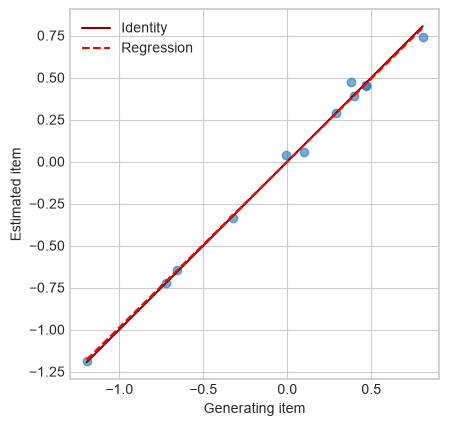

item Pearson correlation:               0.998
item SD ratio (estimated / generating): 0.989
item Regression coefficient:            0.987
item RMSE:                              0.039


In [16]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item', 'my_mfrm_pseudo_halo_item_recovery.png')

Generate a table of threshold statistics (and check run time), and save to file

In [17]:
%%time
mfrm.threshold_stats_df_pseudo_halo(full=True)
mfrm.threshold_stats_pseudo_halo.to_csv('mfrm_pseudo_halo_threshold_stats.csv')

CPU times: user 103 ms, sys: 2.68 ms, total: 106 ms
Wall time: 106 ms


Check the threshold statistics table

In [18]:
mfrm.threshold_stats_pseudo_halo

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-1.982,0.042,-2.046,-1.887,0.990,-0.852,0.995,-0.256,1.021,0.661,0.658
Threshold 2,-0.048,0.035,-0.119,0.019,0.995,-0.451,0.975,-1.276,1.019,0.443,0.443
Threshold 3,0.254,0.037,0.175,0.321,0.990,-0.917,0.988,-0.766,1.035,0.298,0.295
Threshold 4,0.412,0.040,0.331,0.484,0.994,-0.530,0.991,-0.523,1.020,0.339,0.328
Threshold 5,1.365,0.043,1.270,1.434,1.017,1.663,1.019,1.220,0.950,0.484,0.486


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

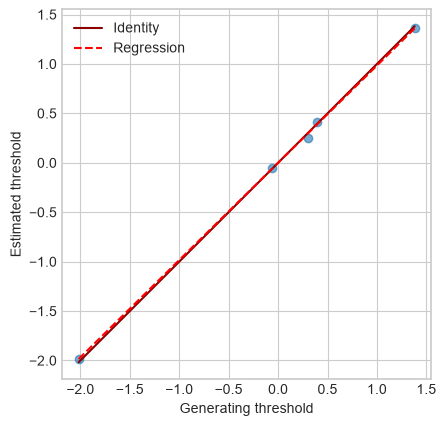

threshold Pearson correlation:               1.0
threshold SD ratio (estimated / generating): 0.984
threshold Regression coefficient:            0.984
threshold RMSE:                              0.028


In [19]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_pseudo_halo_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [20]:
%%time
mfrm.rater_stats_df_pseudo_halo()
mfrm.rater_stats_pseudo_halo.to_csv('mfrm_pseudo_halo_rater_stats.csv')
mfrm.rater_stats_pseudo_halo_full_vector.to_csv('mfrm_pseudo_halo_rater_stats_full_vector.csv')

CPU times: user 50.8 ms, sys: 988 μs, total: 51.8 ms
Wall time: 51.8 ms


Check the rater statistics table

In [21]:
mfrm.rater_stats_pseudo_halo

lambda           omega        Overall statistics                   
        Estimate     SE Estimate     SE              Count Infit MS Outfit MS
Rater_1    1.243  0.048    1.452  0.087             2400.0    0.976     0.976
Rater_2   -0.169  0.038    0.484  0.073             2400.0    0.954     0.958
Rater_3    1.019  0.041    0.632  0.092             2400.0    1.002     0.972
Rater_4   -0.403  0.036    0.866  0.064             2400.0    0.993     0.966
Rater_5   -0.229  0.034    1.060  0.067             2400.0    0.989     0.982
Rater_6   -0.810  0.037    1.475  0.081             2400.0    1.035     1.035
Rater_7   -0.389  0.033    1.090  0.062             2400.0    1.033     1.015
Rater_8   -0.257  0.036    0.940  0.062             2400.0    0.962     0.961

`self.rater_stats_pseudo_halo` (above) is the model's own raw shift/stretch parameters (`lambda`, `omega`), each with its own bootstrap SE. The same call also stores the reconstructed full severity vector separately – what this table showed before this parameterisation had its own dedicated columns:

In [22]:
mfrm.rater_stats_pseudo_halo_full_vector

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1    1.260  0.053    1.448  0.070    1.420  0.065    1.373  0.059   
Rater_2   -0.188  0.042   -0.402  0.053   -0.371  0.050   -0.317  0.049   
Rater_3    1.005  0.045    0.853  0.062    0.876  0.059    0.913  0.051   
Rater_4   -0.408  0.036   -0.464  0.042   -0.455  0.041   -0.442  0.038   
Rater_5   -0.227  0.034   -0.202  0.042   -0.205  0.040   -0.212  0.036   
Rater_6   -0.792  0.042   -0.595  0.055   -0.624  0.053   -0.673  0.046   
Rater_7   -0.386  0.033   -0.348  0.044   -0.354  0.042   -0.363  0.039   
Rater_8   -0.259  0.036   -0.284  0.046   -0.280  0.043   -0.274  0.041   

          Item_5         ... Item_9  Item_10         Item_11         Item_12  \
        Estimate     SE  ...     SE Estimate     SE Estimate     SE Estimate   
Rater_1    1.446  0.070  ...  0.090    1.091  0.054    1.457  0.071    0.951   
Rater_2   -0.401  0.051  ...  0.071    0.005  0.049   -0.413  0.056    0.165   
Rater_3    0.854  0.061  ...  0.082    1.143  0.053    0.845  0.064    1.257   
Rater_4   -0.463  0.043  ...  0.055   -0.358  0.045   -0.466  0.043   -0.316   
Rater_5   -0.202  0.042  ...  0.056   -0.249  0.043   -0.200  0.043   -0.268   
Rater_6   -0.597  0.054  ...  0.072   -0.970  0.053   -0.585  0.054   -1.117   
Rater_7   -0.349  0.043  ...  0.057   -0.419  0.039   -0.346  0.045   -0.447   
Rater_8   -0.284  0.046  ...  0.058   -0.237  0.042   -0.285  0.047   -0.219   

               Overall statistics                     
            SE              Count Infit MS Outfit MS  
Rater_1  0.065             2400.0    0.976     0.976  
Rater_2  0.061             2400.0    0.954     0.958  
Rater_3  0.072             2400.0    1.002     0.972  
Rater_4  0.058             2400.0    0.993     0.966  
Rater_5  0.059             2400.0    0.989     0.982  
Rater_6  0.065             2400.0    1.035     1.035  
Rater_7  0.051             2400.0    1.033     1.015  
Rater_8  0.054             2400.0    0.962     0.961  

[8 rows x 27 columns]

The two parameters `lambda_pseudo_halo` (severity shift) and `omega_pseudo_halo` (item-difficulty stretch) are the two parameters the model produces per rater – `mfrm.raters_pseudo_halo_full_vector` is just their reconstruction back into full (rater x item) form, for compatibility with all the same downstream fit-statistic and plotting machinery the other rater parameterisations use. The term `lambda` is used for the global severity since it is an additive parameter, as for instance in the `items` model, so `lambda` is consistent with the notation used elsewhere in the package. `omega` is used for the stretch parameter, following Jin & Wang (2018)'s own notation for a rater stretch factor – it is a multiplicative parameter rather than an additive one, so has a distinct Greek letter to distinguish it from the additive shift. A rater near `omega=1` is showing undistorted interpretations of item locations; well below 1 is the compressed-perception (pseudo-halo) signature; well above 1 is exaggerating real item location differences.

In [23]:
pd.DataFrame({'lambda (severity)': mfrm.lambda_pseudo_halo, 'omega (stretch)': mfrm.omega_pseudo_halo}).round(3)

,lambda (severity),omega (stretch)
Rater_1,1.243,1.452
Rater_2,-0.169,0.484
Rater_3,1.019,0.632
Rater_4,-0.403,0.866
Rater_5,-0.229,1.060
Rater_6,-0.810,1.475
Rater_7,-0.389,1.090
Rater_8,-0.257,0.940


Pass `alias=True` to `rater_stats_df_pseudo_halo()` to relabel these columns with a human-readable name instead of the raw parameter name – `'Global'` for `lambda`, `'Item stretch'` for `omega` – purely cosmetic, the values themselves are unchanged:

In [24]:
mfrm.rater_stats_df_pseudo_halo(alias=True)
mfrm.rater_stats_pseudo_halo

Global        Item stretch        Overall statistics           \
        Estimate     SE     Estimate     SE              Count Infit MS   
Rater_1    1.243  0.048        1.452  0.087             2400.0    0.976   
Rater_2   -0.169  0.038        0.484  0.073             2400.0    0.954   
Rater_3    1.019  0.041        0.632  0.092             2400.0    1.002   
Rater_4   -0.403  0.036        0.866  0.064             2400.0    0.993   
Rater_5   -0.229  0.034        1.060  0.067             2400.0    0.989   
Rater_6   -0.810  0.037        1.475  0.081             2400.0    1.035   
Rater_7   -0.389  0.033        1.090  0.062             2400.0    1.033   
Rater_8   -0.257  0.036        0.940  0.062             2400.0    0.962   

                   
        Outfit MS  
Rater_1     0.976  
Rater_2     0.958  
Rater_3     0.972  
Rater_4     0.966  
Rater_5     0.982  
Rater_6     1.035  
Rater_7     1.015  
Rater_8     0.961

To add an item-by-item divergence test comparing `pseudo_halo`'s vector reconstruction against `items`' own free per-item estimates to see which rater-item combinations, if any, show significant deviation from the uniform item stretching pattern and then inspect the per-rater flagged items and total count:

`divergence_test='wald'` references the test statistic against the standard normal distribution; `divergence_test='t'` uses a plain Student's t-distribution with `no_of_samples - 1` degrees of freedom instead, correcting (a little) for finite-bootstrap-sample uncertainty in the SE estimate itself. In practice `'t'` is only relevant when `no_of_samples` has deliberately been dropped for speed – at `no_of_samples=300` or more, `'wald'` and `'t'` give essentially the same p-values. With a larger `no_of_samples`, there is no reason to prefer `'t'` over `'wald'`.

Passing `full=True` gives two more ways to see which elements were flagged: one plain True/False column per item is added to the primary table itself, directly after the `'Flagged items'` count, for scanning flagged status across all elements at a glance – and `rater_stats_pseudo_halo_full_vector` receives a per-element `'Flagged'` column added to each item's own `Estimate`/`SE`/CI block displaying the same information alongside. The full `mfrm.rater_stats_pseudo_halo` is displayed here transposed using `.T` for visual convenience.

In [25]:
mfrm.rater_stats_df_pseudo_halo(full=True, divergence_test='wald', correction='bh')
mfrm.rater_stats_pseudo_halo.T

Rater_1 Rater_2 Rater_3 Rater_4 Rater_5 Rater_6  \
lambda             Estimate    1.243  -0.169   1.019  -0.403  -0.229   -0.81   
                   SE          0.049   0.037   0.042   0.039   0.035   0.037   
                   2.5%        1.168  -0.247   0.948  -0.476  -0.307  -0.884   
                   97.5%       1.346  -0.101   1.107  -0.329  -0.173  -0.737   
omega              Estimate    1.452   0.484   0.632   0.866    1.06   1.475   
                   SE          0.089   0.068   0.089   0.063   0.063   0.082   
                   2.5%        1.273   0.354   0.469   0.747   0.934   1.299   
                   97.5%       1.615   0.623   0.804   0.994   1.176   1.622   
Flagged items      Count         0.0     0.0     1.0     0.0     0.0     0.0   
Item_1             Flagged     False   False   False   False   False   False   
Item_2             Flagged     False   False   False   False   False   False   
Item_3             Flagged     False   False   False   False   False   False   
Item_4             Flagged     False   False   False   False   False   False   
Item_5             Flagged     False   False   False   False   False   False   
Item_6             Flagged     False   False   False   False   False   False   
Item_7             Flagged     False   False   False   False   False   False   
Item_8             Flagged     False   False   False   False   False   False   
Item_9             Flagged     False   False   False   False   False   False   
Item_10            Flagged     False   False   False   False   False   False   
Item_11            Flagged     False   False    True   False   False   False   
Item_12            Flagged     False   False   False   False   False   False   
Overall statistics Count      2400.0  2400.0  2400.0  2400.0  2400.0  2400.0   
                   Infit MS    0.976   0.954   1.002   0.993   0.989   1.035   
                   Infit Z    -0.692  -1.518   0.077  -0.221  -0.344   1.055   
                   Outfit MS   0.976   0.958   0.972   0.966   0.982   1.035   
                   Outfit Z   -0.558  -1.176  -0.741  -0.883  -0.479    0.77   

                             Rater_7 Rater_8  
lambda             Estimate   -0.389  -0.257  
                   SE          0.035   0.038  
                   2.5%       -0.462  -0.336  
                   97.5%      -0.324  -0.188  
omega              Estimate     1.09    0.94  
                   SE          0.063   0.066  
                   2.5%         0.96   0.821  
                   97.5%       1.207   1.072  
Flagged items      Count         0.0     0.0  
Item_1             Flagged     False   False  
Item_2             Flagged     False   False  
Item_3             Flagged     False   False  
Item_4             Flagged     False   False  
Item_5             Flagged     False   False  
Item_6             Flagged     False   False  
Item_7             Flagged     False   False  
Item_8             Flagged     False   False  
Item_9             Flagged     False   False  
Item_10            Flagged     False   False  
Item_11            Flagged     False   False  
Item_12            Flagged     False   False  
Overall statistics Count      2400.0  2400.0  
                   Infit MS    1.033   0.962  
                   Infit Z     1.034  -1.236  
                   Outfit MS   1.015   0.961  
                   Outfit Z    0.402  -1.041

And the same recovery check, comparing `mfrm.generating.lambda_`/`mfrm.generating.omega` with the recovered estimates, plotted separately since they're on different scales:

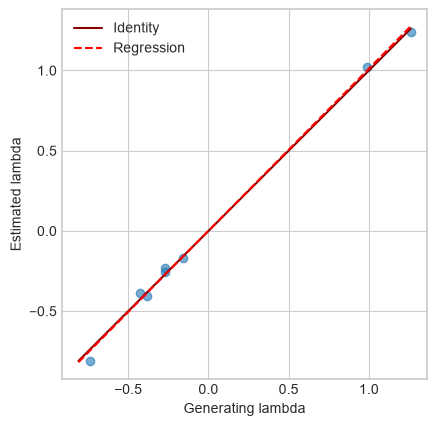

lambda Pearson correlation:               0.999
lambda SD ratio (estimated / generating): 1.012
lambda Regression coefficient:            1.011
lambda RMSE:                              0.036


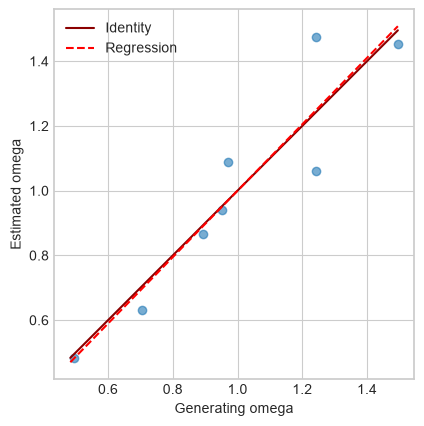

omega Pearson correlation:               0.935
omega SD ratio (estimated / generating): 1.098
omega Regression coefficient:            1.026
omega RMSE:                              0.117


In [26]:
recovery_plot(mfrm.generating.lambda_, mfrm.lambda_pseudo_halo, 'lambda', 'my_mfrm_pseudo_halo_lambda_recovery.png')
recovery_plot(mfrm.generating.omega, mfrm.omega_pseudo_halo, 'omega', 'my_mfrm_pseudo_halo_omega_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [27]:
%%time
mfrm.person_stats_df_pseudo_halo(full=True)
mfrm.person_stats_pseudo_halo.to_csv('mfrm_pseudo_halo_person_stats.csv')

CPU times: user 15.2 ms, sys: 829 μs, total: 16.1 ms
Wall time: 16 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [28]:
mfrm.person_stats_pseudo_halo.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,-2.670,0.179,0.174,43,480,0.090,0.948,0.905,-0.209,-0.430
Person_2,-0.084,0.094,0.092,220,480,0.458,0.959,0.985,-0.260,-0.058
Person_3,1.005,0.103,0.117,340,480,0.708,1.298,1.223,1.861,1.317
Person_4,0.065,0.093,0.092,237,480,0.494,0.972,0.948,-0.167,-0.329
Person_5,1.090,0.105,0.106,348,480,0.725,1.031,1.009,0.247,0.109
Person_6,4.070,0.329,0.311,471,480,0.981,0.891,0.698,-0.174,-0.156
Person_7,-2.036,0.149,0.148,67,480,0.140,0.987,1.060,-0.010,0.390
Person_8,1.225,0.108,0.108,360,480,0.750,0.999,1.119,0.048,0.712
Person_9,-2.377,0.164,0.151,53,480,0.110,0.845,0.835,-0.798,-0.877
Person_10,0.402,0.094,0.094,276,480,0.575,1.000,0.995,0.041,0.012


And the same recovery check for person locations, against `mfrm.generating.persons`:

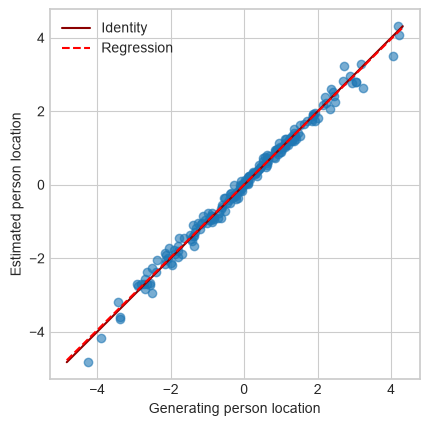

person location Pearson correlation:               0.995
person location SD ratio (estimated / generating): 0.995
person location Regression coefficient:            0.991
person location RMSE:                              0.157


In [29]:
recovery_plot(mfrm.generating.persons, mfrm.persons_pseudo_halo, 'person location', 'my_mfrm_pseudo_halo_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [30]:
%%time
mfrm.test_stats_df_pseudo_halo()
mfrm.test_stats_pseudo_halo.to_csv('mfrm_pseudo_halo_test_stats.csv')

CPU times: user 2.64 ms, sys: 477 μs, total: 3.12 ms
Wall time: 3.13 ms


Check the test statistics table

In [31]:
mfrm.test_stats_pseudo_halo

,Items,Persons
Mean,-0.000,0.007
SD,0.594,1.614
Separation ratio,13.964,12.249
Strata,18.952,16.665
Reliability,0.995,0.993


Run a residual correlation analysis for items (and check run time), and save relevant output to file. This is the diagnostic to pair with `omega_pseudo_halo` for disentangling compressed-perception `pseudo_halo` from genuine local-dependence-based halo effect, as discussed at the top of this notebook.

In [32]:
%%time
mfrm.item_res_corr_analysis_pseudo_halo()
mfrm.item_residual_correlations_pseudo_halo.to_csv('mfrm_pseudo_halo_item_residual_correlations.csv')
mfrm.item_loadings_pseudo_halo.to_csv('mfrm_pseudo_halo_item_loadings.csv')

CPU times: user 8.85 ms, sys: 2.25 ms, total: 11.1 ms
Wall time: 12.4 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [33]:
round(mfrm.item_residual_correlations_pseudo_halo, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,0.017,-0.007,-0.009,0.031,-0.029,-0.055,0.019,-0.028,0.009,-0.012,-0.024
Item_2,0.017,1.000,-0.033,-0.048,-0.019,-0.047,0.001,-0.020,-0.025,-0.050,0.018,-0.033
Item_3,-0.007,-0.033,1.000,-0.019,0.036,0.004,-0.021,0.001,-0.000,-0.039,-0.023,-0.008
Item_4,-0.009,-0.048,-0.019,1.000,-0.038,-0.014,-0.010,-0.022,-0.014,0.025,-0.012,-0.029
Item_5,0.031,-0.019,0.036,-0.038,1.000,-0.059,-0.004,-0.008,-0.005,-0.071,-0.013,-0.026
Item_6,-0.029,-0.047,0.004,-0.014,-0.059,1.000,-0.031,0.024,-0.016,-0.003,-0.037,-0.020
Item_7,-0.055,0.001,-0.021,-0.010,-0.004,-0.031,1.000,-0.047,-0.010,-0.008,-0.003,-0.031
Item_8,0.019,-0.020,0.001,-0.022,-0.008,0.024,-0.047,1.000,-0.025,-0.029,0.006,0.015
Item_9,-0.028,-0.025,-0.000,-0.014,-0.005,-0.016,-0.010,-0.025,1.000,-0.012,-0.021,-0.041
Item_10,0.009,-0.050,-0.039,0.025,-0.071,-0.003,-0.008,-0.029,-0.012,1.000,-0.041,0.010


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [34]:
round(mfrm.item_loadings_pseudo_halo['PC 1'], 3)

Item_1    -0.057
Item_2    -0.125
Item_3    -0.052
Item_4     0.116
Item_5    -0.169
Item_6     0.121
Item_7    -0.014
Item_8    -0.001
Item_9     0.001
Item_10    0.182
Item_11   -0.074
Item_12    0.057
Name: PC 1, dtype: float64

Run a residual correlation analysis for raters (and check run time), and save relevant output to file

In [35]:
%%time
mfrm.rater_res_corr_analysis_pseudo_halo()
mfrm.rater_residual_correlations_pseudo_halo.to_csv('mfrm_pseudo_halo_rater_residual_correlations.csv')
mfrm.rater_loadings_pseudo_halo.to_csv('mfrm_pseudo_halo_rater_loadings.csv')

CPU times: user 13.3 ms, sys: 874 μs, total: 14.2 ms
Wall time: 14.2 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [36]:
round(mfrm.rater_residual_correlations_pseudo_halo, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,0.017,-0.013,-0.001,-0.011,0.030,0.022,0.006
Rater_2,0.017,1.000,0.007,-0.029,0.000,0.001,-0.018,-0.006
Rater_3,-0.013,0.007,1.000,-0.033,-0.011,-0.008,-0.048,0.013
Rater_4,-0.001,-0.029,-0.033,1.000,-0.021,-0.021,-0.029,-0.042
Rater_5,-0.011,0.000,-0.011,-0.021,1.000,-0.014,-0.060,0.052
Rater_6,0.030,0.001,-0.008,-0.021,-0.014,1.000,-0.019,-0.080
Rater_7,0.022,-0.018,-0.048,-0.029,-0.060,-0.019,1.000,-0.038
Rater_8,0.006,-0.006,0.013,-0.042,0.052,-0.080,-0.038,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [37]:
round(mfrm.rater_loadings_pseudo_halo['PC 1'], 3)

Rater_1   -0.126
Rater_2    0.006
Rater_3    0.107
Rater_4   -0.060
Rater_5    0.186
Rater_6   -0.196
Rater_7   -0.132
Rater_8    0.232
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

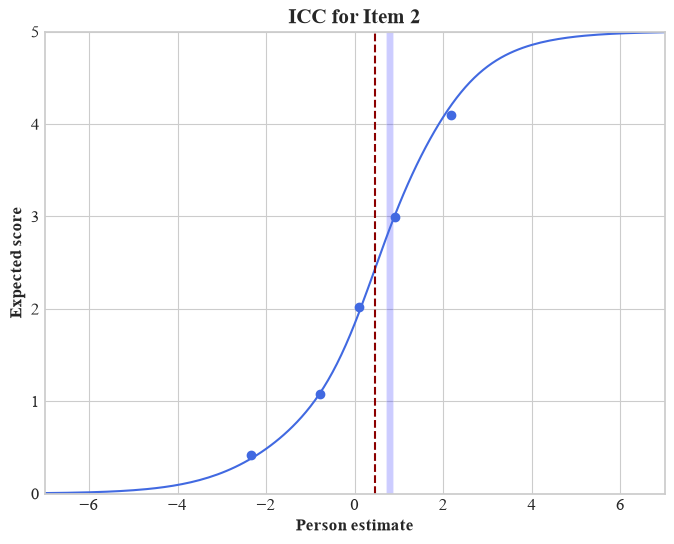

In [38]:
mfrm.icc_pseudo_halo('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

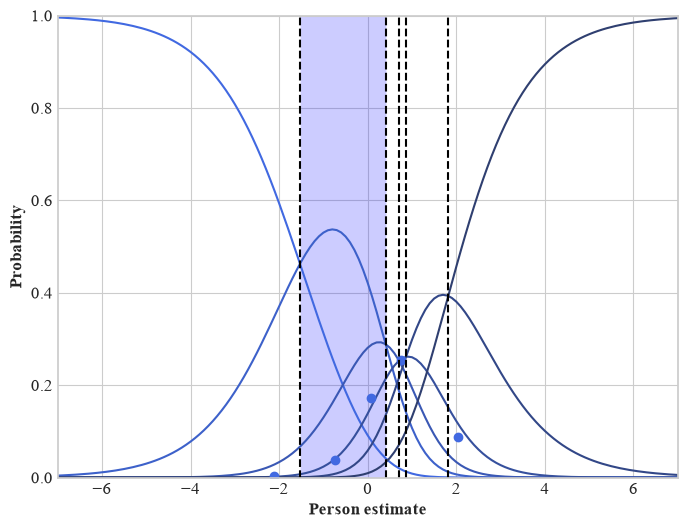

In [39]:
mfrm.crcs_pseudo_halo('Item_2', thresh_lines=True, obs=[3], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 3, category 1 highlighted and the thresholds marked

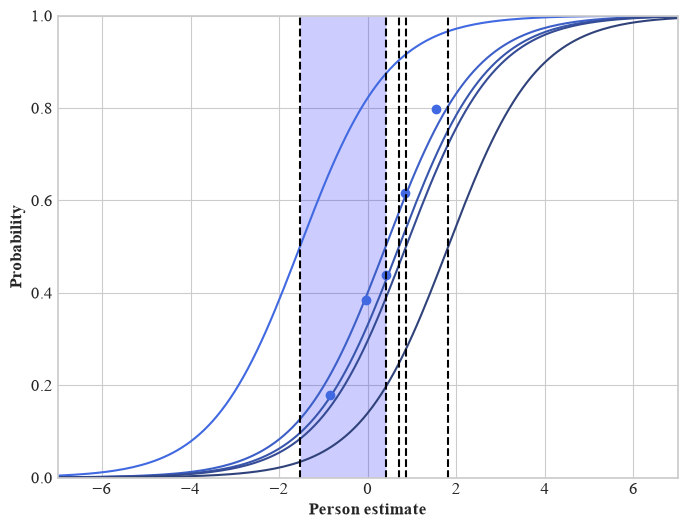

In [40]:
mfrm.threshold_ccs_pseudo_halo('Item_2', thresh_lines=True, obs=[3], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_threshold_ccs')

Produce an item information function curve for Item 2

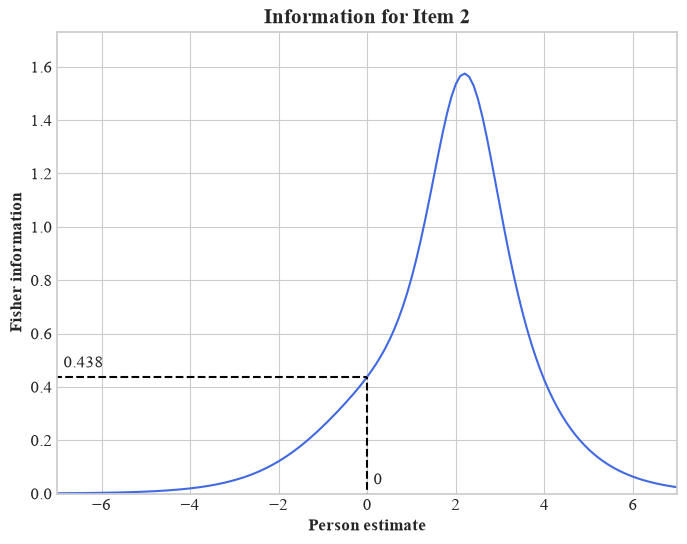

In [41]:
mfrm.iic_pseudo_halo('Item_2', point_info_lines=[0], point_info_labels=True,
                     title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

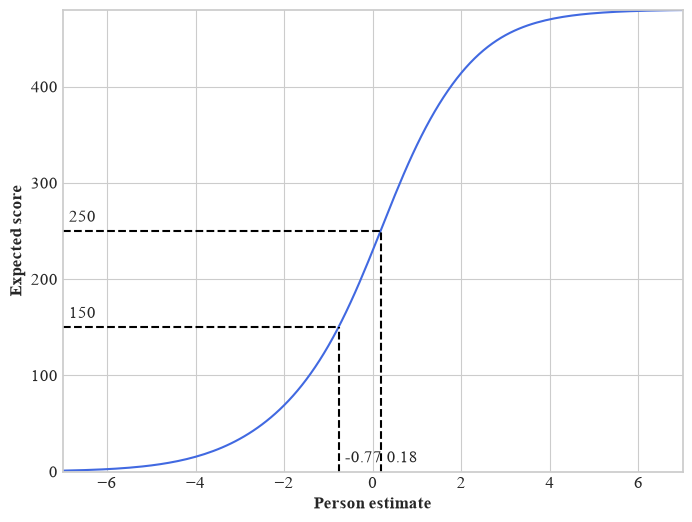

In [42]:
mfrm.tcc_pseudo_halo(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_tcc')

Produce a test information curve

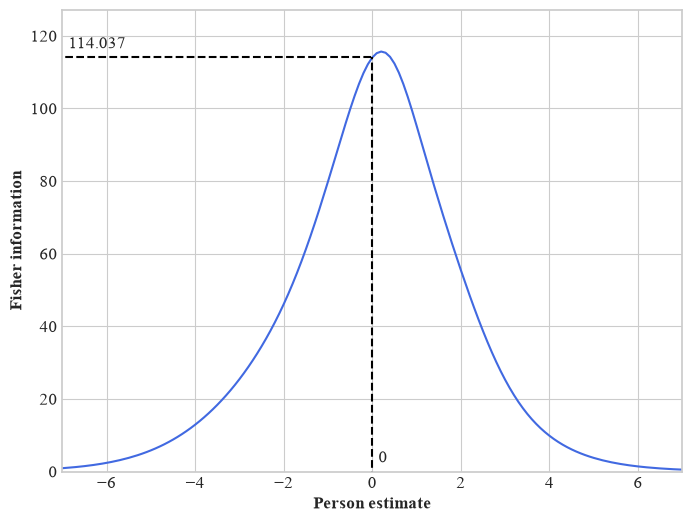

In [43]:
mfrm.test_info_pseudo_halo(point_info_lines=[0], point_info_labels=True,
                           xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

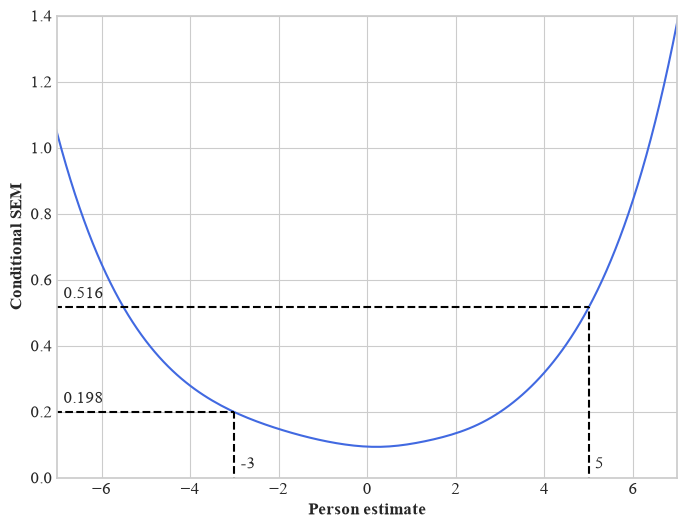

In [44]:
mfrm.test_csem_pseudo_halo(point_csem_lines=[-3, 5], point_csem_labels=True,
                           ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

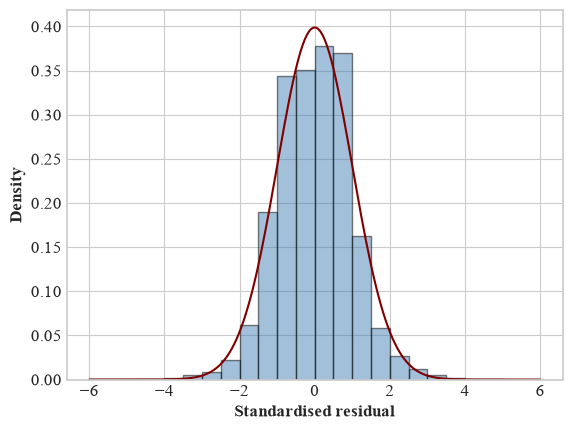

In [45]:
mfrm.std_residuals_plot_pseudo_halo(bin_width=0.6, normal=True, filename='my_mfrm_pseudo_halo_std_residuals_plot')

**Model selection.** Since `pseudo_halo` is nested between `global` and `items`, `model_selection()` can compare it against all eight MFRM rater representations (or a chosen subset via `models=`) directly via AIC, BIC, or LR. See the `Model selection` example notebook for a full worked demonstration, including this exact comparison (`models=['items', 'pseudo_halo']`) run on a `pseudo_halo`-generated data set.

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [46]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_pseudo_halo_anchor(anchors)

CPU times: user 14.3 ms, sys: 2.19 ms, total: 16.5 ms
Wall time: 14.7 ms


Check the anchored item locations against the unanchored ones.

In [47]:
item_check = pd.DataFrame({'Unanchored': mfrm.items,
                           'Anchored': mfrm.anchor_items_pseudo_halo})
round(item_check, 3)

,Unanchored,Anchored
Item_1,0.038,-0.004
Item_2,0.453,0.337
Item_3,0.391,0.259
Item_4,0.288,0.154
Item_5,0.449,0.376
Item_6,0.055,0.015
Item_7,-0.724,-0.610
Item_8,-1.185,-1.018
Item_9,0.742,0.761
Item_10,-0.336,-0.256


Check the anchored rater x item severities against the unanchored ones (two separate dataframes)

In [48]:
round(mfrm.raters_pseudo_halo, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,1.260,1.448,1.420,1.373,1.446,1.268,0.915,0.707,1.578,1.091,1.457,0.951
Rater_2,-0.188,-0.402,-0.371,-0.317,-0.401,-0.197,0.205,0.443,-0.552,0.005,-0.413,0.165
Rater_3,1.005,0.853,0.876,0.913,0.854,0.999,1.286,1.456,0.746,1.143,0.845,1.257
Rater_4,-0.408,-0.464,-0.455,-0.442,-0.463,-0.410,-0.306,-0.244,-0.502,-0.358,-0.466,-0.316
Rater_5,-0.227,-0.202,-0.205,-0.212,-0.202,-0.226,-0.272,-0.300,-0.184,-0.249,-0.200,-0.268
Rater_6,-0.792,-0.595,-0.624,-0.673,-0.597,-0.784,-1.154,-1.373,-0.457,-0.970,-0.585,-1.117
Rater_7,-0.386,-0.348,-0.354,-0.363,-0.349,-0.384,-0.454,-0.496,-0.322,-0.419,-0.346,-0.447
Rater_8,-0.259,-0.284,-0.280,-0.274,-0.284,-0.260,-0.214,-0.186,-0.301,-0.237,-0.285,-0.219


In [49]:
round(mfrm.anchor_raters_pseudo_halo, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.816,1.040,0.988,0.919,1.065,0.828,0.420,0.153,1.317,0.651,1.168,0.460
Rater_2,-0.582,-0.730,-0.696,-0.650,-0.747,-0.590,-0.320,-0.143,-0.914,-0.473,-0.815,-0.346
Rater_3,0.605,0.522,0.541,0.567,0.513,0.601,0.753,0.852,0.419,0.667,0.474,0.738
Rater_4,-0.828,-0.829,-0.829,-0.828,-0.829,-0.828,-0.825,-0.823,-0.831,-0.826,-0.830,-0.825
Rater_5,-0.659,-0.594,-0.609,-0.629,-0.587,-0.655,-0.773,-0.850,-0.514,-0.706,-0.557,-0.761
Rater_6,-1.203,-0.965,-1.020,-1.093,-0.939,-1.190,-1.624,-1.908,-0.671,-1.378,-0.829,-1.581
Rater_7,-0.805,-0.726,-0.745,-0.769,-0.718,-0.801,-0.945,-1.039,-0.629,-0.863,-0.681,-0.931
Rater_8,-0.697,-0.683,-0.687,-0.691,-0.682,-0.697,-0.723,-0.739,-0.666,-0.708,-0.675,-0.720
